# Homework 3 Solutions

這一區整理作業要求，將原本教材中的 DQN 範例改寫成較容易比較的版本。

- HW3-1: 比較 naive DQN 與 replay-buffer DQN 在 `static` 模式的結果，並附上簡短理解報告。
- HW3-2: 在 `player` 模式下實作並比較 Double DQN 與 Dueling DQN。
- HW3-3: 將 `random` 模式的 DQN 訓練流程改寫成 PyTorch Lightning，並加入梯度裁剪與學習率排程。

In [3]:
from dataclasses import dataclass
from collections import deque
from pathlib import Path
import copy
import random
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset

SEED = 7
pl.seed_everything(SEED, workers=True)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

GRIDWORLD_FILES = {
    'Gridworld.py': 'https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/Gridworld.py',
    'GridBoard.py': 'https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/GridBoard.py',
}


def ensure_gridworld_files():
    for filename, url in GRIDWORLD_FILES.items():
        path = Path(filename)
        if not path.exists():
            urllib.request.urlretrieve(url, path)


ensure_gridworld_files()
from Gridworld import Gridworld

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ACTION_SET = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}
MOVE_POS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
STATE_SIZE = 64
ACTION_SIZE = 4


@dataclass
class TrainConfig:
    mode: str = 'static'
    episodes: int = 120
    max_moves: int = 20
    gamma: float = 0.95
    lr: float = 1e-3
    epsilon_start: float = 1.0
    epsilon_end: float = 0.1
    epsilon_decay: float = 0.985
    batch_size: int = 64
    replay_size: int = 2000
    warmup_steps: int = 64
    target_sync: int = 40
    hidden_sizes: tuple = (128, 128)
    use_replay: bool = True
    use_target: bool = True
    double: bool = False
    dueling: bool = False
    clip_grad: float | None = 1.0
    scheduler_step: int = 60
    scheduler_gamma: float = 0.8
    wall_penalty: bool = False


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack(states),
            torch.tensor(actions, dtype=torch.long),
            torch.tensor(rewards, dtype=torch.float32),
            torch.stack(next_states),
            torch.tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE, hidden_sizes=(128, 128)):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], action_size),
        )

    def forward(self, x):
        return self.layers(x)


class DuelingQNetwork(nn.Module):
    def __init__(self, state_size=STATE_SIZE, action_size=ACTION_SIZE, hidden_sizes=(128, 128)):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
        )
        self.value_head = nn.Linear(hidden_sizes[1], 1)
        self.advantage_head = nn.Linear(hidden_sizes[1], action_size)

    def forward(self, x):
        features = self.feature(x)
        values = self.value_head(features)
        advantages = self.advantage_head(features)
        return values + advantages - advantages.mean(dim=1, keepdim=True)


def build_network(config: TrainConfig):
    network_cls = DuelingQNetwork if config.dueling else QNetwork
    return network_cls(hidden_sizes=config.hidden_sizes).to(DEVICE)


def encode_state(game, noise_scale=0.01):
    state = game.board.render_np().reshape(-1).astype(np.float32)
    if noise_scale:
        state = state + np.random.rand(STATE_SIZE).astype(np.float32) * noise_scale
    return torch.from_numpy(state)


def choose_action(model, state, epsilon):
    if random.random() < epsilon:
        return random.randrange(ACTION_SIZE)
    with torch.no_grad():
        q_values = model(state.unsqueeze(0).to(DEVICE)).cpu()
    return int(torch.argmax(q_values, dim=1).item())


def evaluate_policy(model, mode='static', episodes=50, max_moves=20, wall_penalty=False):
    model.eval()
    wins = 0
    rewards = []
    for _ in range(episodes):
        game = Gridworld(size=4, mode=mode)
        state = encode_state(game, noise_scale=0.0)
        episode_reward = 0.0
        for _ in range(max_moves):
            action = choose_action(model, state, epsilon=0.0)
            hit_wall = wall_penalty and game.validateMove('Player', MOVE_POS[action]) == 1
            game.makeMove(ACTION_SET[action])
            state = encode_state(game, noise_scale=0.0)
            reward = -5.0 if hit_wall else float(game.reward())
            episode_reward += reward
            if reward != -1:
                if reward > 0:
                    wins += 1
                break
        rewards.append(episode_reward)
    return {
        'wins': wins,
        'win_rate': wins / episodes,
        'avg_reward': float(np.mean(rewards)),
    }


def train_dqn(config: TrainConfig):
    policy_net = build_network(config)
    target_net = build_network(config)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = Adam(policy_net.parameters(), lr=config.lr)
    scheduler = StepLR(optimizer, step_size=config.scheduler_step, gamma=config.scheduler_gamma)
    loss_fn = nn.MSELoss()
    replay_buffer = ReplayBuffer(config.replay_size)
    epsilon = config.epsilon_start
    losses = []
    episode_rewards = []
    total_steps = 0

    for _ in range(config.episodes):
        game = Gridworld(size=4, mode=config.mode)
        state = encode_state(game)
        episode_reward = 0.0
        updates_this_episode = 0

        for _ in range(config.max_moves):
            action = choose_action(policy_net, state, epsilon)
            hit_wall = config.wall_penalty and game.validateMove('Player', MOVE_POS[action]) == 1
            game.makeMove(ACTION_SET[action])
            next_state = encode_state(game)
            reward = -5.0 if hit_wall else float(game.reward())
            done = reward != -1
            replay_buffer.push(state.clone(), action, reward, next_state.clone(), done)
            episode_reward += reward
            state = next_state

            enough_replay = len(replay_buffer) >= max(config.batch_size, config.warmup_steps)
            if config.use_replay and enough_replay:
                batch = replay_buffer.sample(config.batch_size)
            elif not config.use_replay:
                batch = (
                    replay_buffer.buffer[-1][0].unsqueeze(0),
                    torch.tensor([action], dtype=torch.long),
                    torch.tensor([reward], dtype=torch.float32),
                    next_state.unsqueeze(0),
                    torch.tensor([done], dtype=torch.float32),
                )
            else:
                if done:
                    break
                continue

            states, actions, rewards, next_states, dones = [item.to(DEVICE) for item in batch]
            q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

            with torch.no_grad():
                if config.use_target:
                    if config.double:
                        next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
                        next_q_values = target_net(next_states).gather(1, next_actions).squeeze(1)
                    else:
                        next_q_values = target_net(next_states).max(dim=1).values
                else:
                    next_q_values = policy_net(next_states).max(dim=1).values
                targets = rewards + config.gamma * (1 - dones) * next_q_values

            loss = loss_fn(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            if config.clip_grad is not None:
                nn.utils.clip_grad_norm_(policy_net.parameters(), config.clip_grad)
            optimizer.step()
            updates_this_episode += 1
            losses.append(float(loss.item()))
            total_steps += 1

            if config.use_target and total_steps % config.target_sync == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        episode_rewards.append(episode_reward)
        epsilon = max(config.epsilon_end, epsilon * config.epsilon_decay)
        if updates_this_episode > 0:
            scheduler.step()

    return {
        'model': policy_net.cpu(),
        'target_model': target_net.cpu(),
        'losses': losses,
        'episode_rewards': episode_rewards,
        'config': config,
    }


def plot_training_curves(runs, metric='losses', title='Training curves'):
    plt.figure(figsize=(10, 5))
    for label, run in runs.items():
        values = run[metric]
        if not values:
            continue
        plt.plot(values, label=label)
    plt.title(title)
    plt.xlabel('Step' if metric == 'losses' else 'Episode')
    plt.ylabel('Loss' if metric == 'losses' else 'Reward')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

print(f'Running on device: {DEVICE}')

Seed set to 7


Running on device: cpu


## HW3-1: Naive DQN vs Replay Buffer (`static` mode)

### Short understanding report

1. Naive DQN 直接用當下 transition 更新 Q-network，優點是寫法直觀，但資料高度相關，容易讓訓練震盪。
2. Experience Replay Buffer 會把 `(state, action, reward, next_state, done)` 存起來，再隨機抽樣訓練，能降低資料相關性，讓梯度估計更穩定。
3. 在這個 `static` Gridworld 中，任務相對簡單，因此 naive DQN 通常也能學到策略；但 replay buffer 通常會帶來更平滑的 loss 與更好的泛化。
4. DQN 的核心是用 Bellman target 逼近 `Q(s, a)`，而不是直接學分類標籤。模型學的是「某個動作未來累積報酬的估計值」。

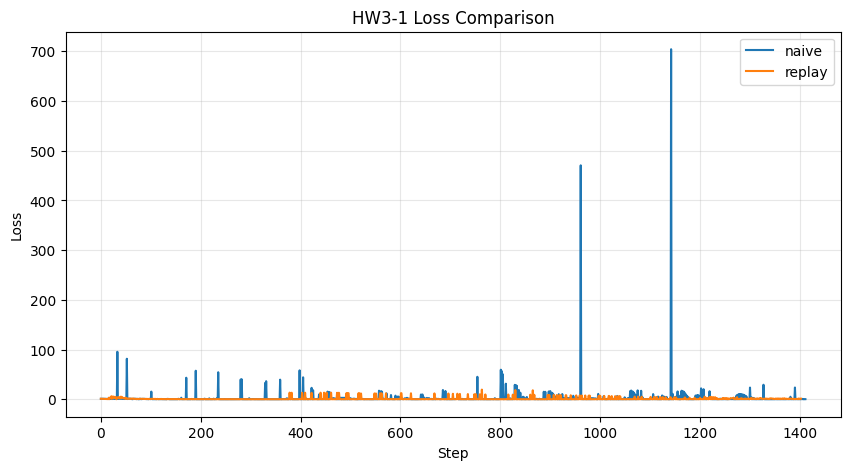

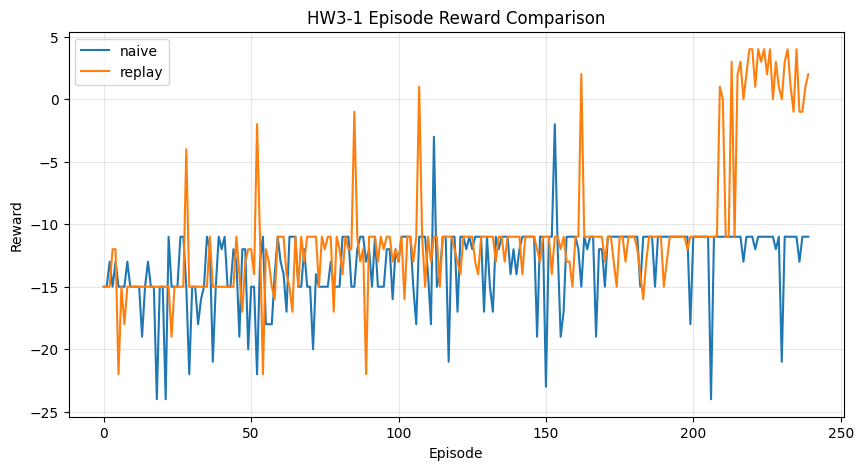

{'naive_dqn': {'wins': 0, 'win_rate': 0.0, 'avg_reward': -11.0},
 'replay_dqn': {'wins': 40, 'win_rate': 1.0, 'avg_reward': 4.0}}

In [4]:
naive_static_run = train_dqn(
    TrainConfig(
        mode='static',
        episodes=240,
        max_moves=15,
        use_replay=False,
        use_target=False,
        batch_size=1,
        warmup_steps=1,
        epsilon_decay=0.992,
        scheduler_step=80,
    )
)

replay_static_run = train_dqn(
    TrainConfig(
        mode='static',
        episodes=240,
        max_moves=15,
        use_replay=True,
        use_target=True,
        batch_size=32,
        warmup_steps=32,
        target_sync=20,
        epsilon_decay=0.992,
        scheduler_step=80,
    )
)

static_results = {
    'naive_dqn': evaluate_policy(naive_static_run['model'], mode='static', episodes=40, max_moves=15),
    'replay_dqn': evaluate_policy(replay_static_run['model'], mode='static', episodes=40, max_moves=15),
}

plot_training_curves({'naive': naive_static_run, 'replay': replay_static_run}, metric='losses', title='HW3-1 Loss Comparison')
plot_training_curves({'naive': naive_static_run, 'replay': replay_static_run}, metric='episode_rewards', title='HW3-1 Episode Reward Comparison')
static_results

## HW3-2: Double DQN and Dueling DQN (`player` mode)

這一部分固定使用 replay buffer 與 target network，再分別打開 `double=True` 與 `dueling=True`，用相同的訓練回合數比較表現。

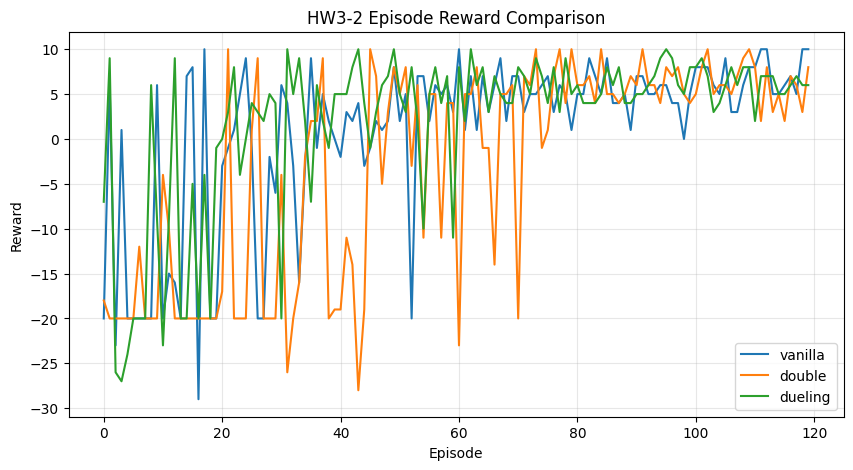

{'vanilla_dqn': {'wins': 50, 'win_rate': 1.0, 'avg_reward': 7.02},
 'double_dqn': {'wins': 50, 'win_rate': 1.0, 'avg_reward': 6.64},
 'dueling_dqn': {'wins': 50, 'win_rate': 1.0, 'avg_reward': 6.3}}

In [5]:
base_player_run = train_dqn(
    TrainConfig(
        mode='player',
        episodes=120,
        max_moves=20,
        use_replay=True,
        use_target=True,
        batch_size=32,
        warmup_steps=32,
        target_sync=20,
        epsilon_decay=0.975,
    )
)

double_player_run = train_dqn(
    TrainConfig(
        mode='player',
        episodes=120,
        max_moves=20,
        use_replay=True,
        use_target=True,
        double=True,
        batch_size=32,
        warmup_steps=32,
        target_sync=20,
        epsilon_decay=0.975,
    )
)

dueling_player_run = train_dqn(
    TrainConfig(
        mode='player',
        episodes=120,
        max_moves=20,
        use_replay=True,
        use_target=True,
        dueling=True,
        batch_size=32,
        warmup_steps=32,
        target_sync=20,
        epsilon_decay=0.975,
    )
)

player_results = {
    'vanilla_dqn': evaluate_policy(base_player_run['model'], mode='player', episodes=50, max_moves=20),
    'double_dqn': evaluate_policy(double_player_run['model'], mode='player', episodes=50, max_moves=20),
    'dueling_dqn': evaluate_policy(dueling_player_run['model'], mode='player', episodes=50, max_moves=20),
}

plot_training_curves(
    {
        'vanilla': base_player_run,
        'double': double_player_run,
        'dueling': dueling_player_run,
    },
    metric='episode_rewards',
    title='HW3-2 Episode Reward Comparison',
)
player_results

## HW3-3: PyTorch Lightning version (`random` mode)

這裡將 DQN 訓練流程包成 Lightning module，並加入兩個常見 training tips:

- gradient clipping: 限制梯度範數，降低不穩定更新
- learning rate scheduler: 讓學習率隨訓練遞減

另外保留 replay buffer、target network、Double DQN，並加上撞牆懲罰，讓 `random` 模式更容易收斂。

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name       | Type            | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | policy_net | DuelingQNetwork | 25.5 K | train | 0    
1 | target_net | DuelingQNetwork | 25.5 K | train | 0    
2 | loss_fn    | MSELoss         | 0      | train | 0    
---------------------------------------------------------------
51.0 K    Trainable params
0         Non-trainable params
51.0 K    Total params
0.204     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 0: 100%|██████████| 1000/1000 [00:20<00:00, 49.49it/s, train_loss_step=6.260, episode_reward_step=-11.0, epsilon_step=0.100, train_loss_epoch=4.890, episode_reward_epoch=-4.64, epsilon_epoch=0.322]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 1000/1000 [00:20<00:00, 49.48it/s, train_loss_step=6.260, episode_reward_step=-11.0, epsilon_step=0.100, train_loss_epoch=4.890, episode_reward_epoch=-4.64, epsilon_epoch=0.322]


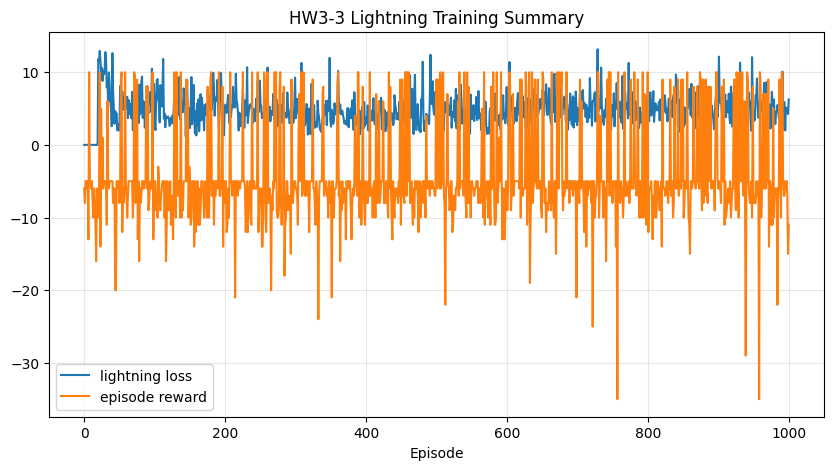

{'wins': 11, 'win_rate': 0.22, 'avg_reward': -4.92}

In [8]:
class EpisodeDataset(Dataset):
    def __init__(self, episodes: int):
        self.episodes = episodes

    def __len__(self):
        return self.episodes

    def __getitem__(self, idx):
        return idx


class LightningDQN(pl.LightningModule):
    def __init__(self, config: TrainConfig):
        super().__init__()
        self.config = config
        self.save_hyperparameters(ignore=['config'])
        self.automatic_optimization = False
        self.policy_net = build_network(config)
        self.target_net = build_network(config)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(config.replay_size)
        self.epsilon = config.epsilon_start
        self.total_steps = 0
        self.loss_history = []
        self.reward_history = []

    def configure_optimizers(self):
        optimizer = Adam(self.policy_net.parameters(), lr=self.config.lr)
        scheduler = StepLR(optimizer, step_size=self.config.scheduler_step, gamma=self.config.scheduler_gamma)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        optimizer = self.optimizers()
        scheduler = self.lr_schedulers()
        game = Gridworld(size=4, mode=self.config.mode)
        state = encode_state(game)
        episode_reward = 0.0
        step_losses = []
        updates_this_episode = 0

        for _ in range(self.config.max_moves):
            action = choose_action(self.policy_net, state, self.epsilon)
            hit_wall = self.config.wall_penalty and game.validateMove('Player', MOVE_POS[action]) == 1
            game.makeMove(ACTION_SET[action])
            next_state = encode_state(game)
            reward = -5.0 if hit_wall else float(game.reward())
            done = reward != -1
            self.replay_buffer.push(state.clone(), action, reward, next_state.clone(), done)
            state = next_state
            episode_reward += reward

            if len(self.replay_buffer) >= max(self.config.batch_size, self.config.warmup_steps):
                states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.config.batch_size)
                states = states.to(self.device)
                actions = actions.to(self.device)
                rewards = rewards.to(self.device)
                next_states = next_states.to(self.device)
                dones = dones.to(self.device)

                q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
                    next_q_values = self.target_net(next_states).gather(1, next_actions).squeeze(1)
                    targets = rewards + self.config.gamma * (1 - dones) * next_q_values

                loss = self.loss_fn(q_values, targets)
                optimizer.zero_grad()
                self.manual_backward(loss)
                if self.config.clip_grad is not None:
                    self.clip_gradients(
                        optimizer,
                        gradient_clip_val=self.config.clip_grad,
                        gradient_clip_algorithm='norm',
                    )
                optimizer.step()
                step_losses.append(loss.detach())
                updates_this_episode += 1
                self.total_steps += 1

                if self.total_steps % self.config.target_sync == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())

            if done:
                break

        if updates_this_episode > 0:
            scheduler.step()
        self.epsilon = max(self.config.epsilon_end, self.epsilon * self.config.epsilon_decay)
        mean_loss = torch.stack(step_losses).mean() if step_losses else torch.tensor(0.0, device=self.device)
        self.loss_history.append(float(mean_loss.detach().cpu().item()))
        self.reward_history.append(float(episode_reward))
        self.log('train_loss', mean_loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('episode_reward', torch.tensor(episode_reward, device=self.device), prog_bar=True, on_step=True, on_epoch=True)
        self.log('epsilon', torch.tensor(self.epsilon, device=self.device), prog_bar=True, on_step=True, on_epoch=True)
        return mean_loss


lightning_random_config = TrainConfig(
    mode='random',
    episodes=1000,
    max_moves=35,
    gamma=0.99,
    lr=5e-4,
    use_replay=True,
    use_target=True,
    double=True,
    dueling=True,
    batch_size=64,
    warmup_steps=64,
    replay_size=6000,
    target_sync=20,
    epsilon_decay=0.997,
    wall_penalty=True,
    clip_grad=0.8,
    scheduler_step=150,
    scheduler_gamma=0.92,
)

lightning_random_agent = LightningDQN(lightning_random_config)
lightning_loader = DataLoader(EpisodeDataset(lightning_random_config.episodes), batch_size=1)
lightning_trainer = pl.Trainer(
    max_epochs=1,
    accelerator='auto',
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
)
lightning_trainer.fit(lightning_random_agent, train_dataloaders=lightning_loader)

lightning_random_results = evaluate_policy(
    lightning_random_agent.policy_net.cpu(),
    mode='random',
    episodes=50,
    max_moves=35,
    wall_penalty=True,
)

plt.figure(figsize=(10, 5))
plt.plot(lightning_random_agent.loss_history, label='lightning loss')
plt.plot(lightning_random_agent.reward_history, label='episode reward')
plt.title('HW3-3 Lightning Training Summary')
plt.xlabel('Episode')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lightning_random_results